# Fase 2c — Modelos por familia de fallo vs modelo único de flota
### TFM: Arquitectura de Mantenimiento Predictivo

Pregunta a zanjar con datos: para predecir RUL (prognosis), ¿es mejor **un modelo por familia
de modo de fallo** (especialistas) o **un único modelo de flota** (generalista)?

Diseño del experimento, justo para comparar manzanas con manzanas:
- Definimos familias por modo de fallo (HPT, HPT+LPT, Fan, HPC, LPT, all...).
- Para cada subconjunto de **test**, lo evaluamos con DOS modelos:
  1. El **modelo único** entrenado con toda la flota.
  2. El **modelo especialista** entrenado solo con los subconjuntos de **su misma familia**
     (excluyendo el propio subconjunto de test, para no hacer trampa).
- Comparamos RMSE, sesgo y score NASA por subconjunto y en agregado.

Hipótesis previa (a confirmar o refutar): el modelo único rinde igual o mejor en agregado,
porque cada especialista entrena con menos datos y un rango de vidas más estrecho, y el error
dominante (sesgo por longitud de vida) no depende del modo de fallo.

Autocontenido. Tiempo aproximado: ~15-20 min (un modelo de flota + un modelo por familia).

In [1]:
import os, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, h5py
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
warnings.filterwarnings('ignore')

SEED = 42; SUBSAMPLE = 20; EVAL_SUBSAMPLE = 10; RUL_CAP = 57
ROLL_WINDOWS = (5, 10); SLOPE_W = 10
np.random.seed(SEED)

FILES = {
    'DS01': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS01-005.h5',
    'DS02': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5',
    'DS03': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS03-012.h5',
    'DS04': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS04.h5',
    'DS05': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS05.h5',
    'DS06': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS06.h5',
    'DS07': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS07.h5',
    'DS08a': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08a-009.h5',
    'DS08c': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08c-008.h5',
}
# Familia de modo de fallo por subconjunto (APROXIMADO; ajusta si tu doc dice otra cosa).
FAMILY = {'DS01':'HPT', 'DS02':'HPT+LPT', 'DS03':'HPT+LPT', 'DS04':'Fan',
          'DS05':'HPC', 'DS06':'HPC_LPT', 'DS07':'LPT', 'DS08a':'all', 'DS08c':'all'}
DS_CODE = {name: i for i, name in enumerate(FILES)}

base_params = dict(n_estimators=600, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                   reg_lambda=1.0, reg_alpha=0.1, random_state=SEED, n_jobs=-1,
                   importance_type='gain', eval_metric='rmse', early_stopping_rounds=30)

present = [n for n, p in FILES.items() if os.path.exists(p)]
print('Presentes:', present)
print('Familias  :', {f: [s for s in present if FAMILY[s]==f] for f in sorted(set(FAMILY[s] for s in present))})

Presentes: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']
Familias  : {'Fan': ['DS04'], 'HPC': ['DS05'], 'HPC_LPT': ['DS06'], 'HPT': ['DS01'], 'HPT+LPT': ['DS02', 'DS03'], 'LPT': ['DS07'], 'all': ['DS08a', 'DS08c']}


## 1. Cargador, features y utilidades

In [2]:
def load_subset(path, split, name):
    with h5py.File(path, 'r') as f:
        W   = np.array(f[f'W_{split}'],   dtype=np.float32)
        X_s = np.array(f[f'X_s_{split}'], dtype=np.float32)
        A   = np.array(f[f'A_{split}'],   dtype=np.float32)
        Y   = np.array(f[f'Y_{split}'],   dtype=np.float32)
        W_var  = [v.decode() for v in f['W_var'][:]]
        Xs_var = [v.decode() for v in f['X_s_var'][:]]
        A_var  = [v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i = A_var.index('hs'); A = np.delete(A, i, axis=1); A_var = [v for v in A_var if v != 'hs']
    df = pd.DataFrame(np.hstack([A, W, X_s, Y.reshape(-1, 1)]),
                      columns=A_var + W_var + Xs_var + ['RUL'])
    for c in ['unit', 'cycle', 'Fc']: df[c] = df[c].astype(int)
    df['dataset'] = name; df['ds_code'] = DS_CODE[name]
    df['engine_id'] = name + '_u' + df['unit'].astype(str)
    return df, W_var, Xs_var

def cycle_level_features(df, sensors, windows=ROLL_WINDOWS, slope_w=SLOPE_W):
    df = df.sort_values(['engine_id', 'cycle'])
    cyc = df.groupby(['engine_id', 'cycle'])[sensors].mean().reset_index().sort_values(['engine_id', 'cycle'])
    rc = []
    for w in windows:
        for col in sensors:
            cyc[f'{col}_roll{w}_mean'] = cyc.groupby('engine_id')[col].transform(lambda x: x.rolling(w, min_periods=1).mean())
            cyc[f'{col}_roll{w}_std']  = cyc.groupby('engine_id')[col].transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            rc += [f'{col}_roll{w}_mean', f'{col}_roll{w}_std']
    def slope(x, w):
        a = x.values; out = np.zeros(len(a))
        for i in range(len(a)):
            seg = a[max(0, i - w + 1): i + 1]
            if len(seg) >= 2: out[i] = np.polyfit(np.arange(len(seg)), seg, 1)[0]
        return pd.Series(out, index=x.index)
    for col in sensors:
        cyc[f'{col}_slope{slope_w}'] = cyc.groupby('engine_id')[col].transform(lambda x: slope(x, slope_w)); rc.append(f'{col}_slope{slope_w}')
    stats = df.groupby(['engine_id', 'cycle'])[sensors].agg(['max', 'std'])
    stats.columns = [f'{s}_cyc_{a}' for s, a in stats.columns]; stats = stats.fillna(0.0).reset_index()
    return cyc[['engine_id', 'cycle'] + rc].merge(stats, on=['engine_id', 'cycle'])

def add_pos_relativa(df):
    df = df.sort_values(['engine_id', 'cycle']).reset_index(drop=True)
    pos = df.groupby(['engine_id', 'cycle']).cumcount()
    size = df.groupby(['engine_id', 'cycle'])['cycle'].transform('size') - 1
    df['pos_relativa'] = (pos / size.replace(0, 1)).astype(np.float32); return df

def assemble(df, cyc_feat, sensors, w_var, subsample=None):
    df = add_pos_relativa(df)
    keep = ['engine_id', 'dataset', 'ds_code', 'unit', 'cycle', 'Fc', 'RUL'] + sensors + w_var + ['pos_relativa']
    obs = df[keep]
    if subsample: obs = obs.sample(frac=1.0 / subsample, random_state=SEED)
    obs = obs.copy(); obs['age'] = obs['cycle'].astype(np.float32)
    return obs.merge(cyc_feat, on=['engine_id', 'cycle'], how='left')

def nasa_score(yr, yp):
    d = np.asarray(yp) - np.asarray(yr)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

In [3]:
SENSORS, WVARS, FEATURES = None, None, None
def _set_schema(Xv, Wv):
    global SENSORS, WVARS, FEATURES
    SENSORS, WVARS = Xv, Wv
    cyc = []
    for w in ROLL_WINDOWS:
        for s in SENSORS: cyc += [f'{s}_roll{w}_mean', f'{s}_roll{w}_std']
    for s in SENSORS: cyc += [f'{s}_slope{SLOPE_W}']
    for s in SENSORS: cyc += [f'{s}_cyc_max', f'{s}_cyc_std']
    FEATURES = SENSORS + WVARS + ['pos_relativa', 'age', 'Fc', 'ds_code'] + cyc

def build_train(subsets, subsample=SUBSAMPLE):
    parts = []
    for name in subsets:
        if not os.path.exists(FILES[name]): continue
        df, Wv, Xv = load_subset(FILES[name], 'dev', name)
        if SENSORS is None: _set_schema(Xv, Wv)
        cyc = cycle_level_features(df, SENSORS)
        parts.append(assemble(df, cyc, SENSORS, WVARS, subsample=subsample)); del df, cyc
    return pd.concat(parts, ignore_index=True)

def train_model(train):
    y = np.minimum(train['RUL'].values, RUL_CAP)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    tr, es = next(gss.split(train, y, train['engine_id']))
    m = xgb.XGBRegressor(**base_params)
    m.fit(train.iloc[tr][FEATURES].values, y[tr],
          eval_set=[(train.iloc[es][FEATURES].values, y[es])], verbose=False)
    return m

def eval_on_test(model, subset, subsample=EVAL_SUBSAMPLE, chunk=300_000):
    """Memoria controlada: submuestrea test, predice por trozos en float32."""
    df, _, _ = load_subset(FILES[subset], 'test', subset)
    cyc = cycle_level_features(df, SENSORS)
    mat = assemble(df, cyc, SENSORS, WVARS, subsample=subsample); del df, cyc
    X = mat[FEATURES].to_numpy(dtype=np.float32, copy=False)
    preds = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), chunk):
        preds[i:i+chunk] = model.predict(X[i:i+chunk])
    del X
    t = mat[['unit', 'cycle', 'RUL']].copy(); t['pred'] = preds; del mat
    g = t.groupby(['unit', 'cycle']).agg(real=('RUL','first'), pred=('pred','median')).reset_index()
    g['real_cap'] = np.minimum(g.real, RUL_CAP)
    rmse = mean_squared_error(g.real_cap, g.pred) ** .5
    sesgo = (g.pred - g.real_cap).mean()
    nasa_c = nasa_score(g.real_cap, g.pred) / len(g)
    return {'RMSE': rmse, 'sesgo': sesgo, 'NASA_x_ciclo': nasa_c, 'n_ciclos': len(g)}

print('Listo.')

Listo.


## 2. Modelo único de flota (generalista)

In [4]:
t0 = time.time()
train_full = build_train(present)
model_full = train_model(train_full)
print(f'Modelo único entrenado ({time.time()-t0:.0f}s) | {train_full["engine_id"].nunique()} motores')
del train_full

Modelo único entrenado (704s) | 60 motores


## 3. Modelos por familia (especialistas)

Para cada subconjunto de test, su especialista se entrena con los subconjuntos de **su misma
familia, excluyendo el propio subconjunto de test** (evaluación honesta: nunca entrena con el
motor que va a predecir). Si una familia solo tiene ese subconjunto, no hay especialista posible
(se marca como n/d) — un punto importante a favor del modelo único.

In [5]:
rows = []
specialist_cache = {}
for test_sub in present:
    fam = FAMILY[test_sub]
    fam_subsets = [s for s in present if FAMILY[s] == fam and s != test_sub]   # misma familia, sin el de test

    r_full = eval_on_test(model_full, test_sub)   # generalista

    if not fam_subsets:
        r_spec = {'RMSE': np.nan, 'sesgo': np.nan, 'NASA_x_ciclo': np.nan}
        nota = 'sin otra fuente en la familia'
    else:
        key = tuple(sorted(fam_subsets))
        if key not in specialist_cache:
            specialist_cache[key] = train_model(build_train(list(key)))
        r_spec = eval_on_test(specialist_cache[key], test_sub)
        nota = '+'.join(fam_subsets)

    rows.append({'test': test_sub, 'familia': fam, 'entreno_especialista': nota,
                 'RMSE_unico': r_full['RMSE'], 'RMSE_espec': r_spec['RMSE'],
                 'sesgo_unico': r_full['sesgo'], 'sesgo_espec': r_spec['sesgo'],
                 'NASA_unico': r_full['NASA_x_ciclo'], 'NASA_espec': r_spec['NASA_x_ciclo']})
    print(f'  {test_sub} ({fam}): RMSE unico={r_full["RMSE"]:.2f} | especialista={r_spec["RMSE"]:.2f}')

comp = pd.DataFrame(rows)
print('\n===== Comparación por subconjunto ====='); print(comp.round(2).to_string(index=False))

  DS01 (HPT): RMSE unico=5.29 | especialista=nan
  DS02 (HPT+LPT): RMSE unico=7.69 | especialista=8.99
  DS03 (HPT+LPT): RMSE unico=6.02 | especialista=8.69
  DS04 (Fan): RMSE unico=9.24 | especialista=nan
  DS05 (HPC): RMSE unico=6.05 | especialista=nan
  DS06 (HPC_LPT): RMSE unico=5.39 | especialista=nan
  DS07 (LPT): RMSE unico=6.67 | especialista=nan
  DS08a (all): RMSE unico=7.47 | especialista=7.53
  DS08c (all): RMSE unico=6.57 | especialista=7.87

===== Comparación por subconjunto =====
 test familia          entreno_especialista  RMSE_unico  RMSE_espec  sesgo_unico  sesgo_espec  NASA_unico  NASA_espec
 DS01     HPT sin otra fuente en la familia        5.29         NaN         0.91          NaN        0.53         NaN
 DS02 HPT+LPT                          DS03        7.69        8.99        -0.31        -4.29        0.89        0.97
 DS03 HPT+LPT                          DS02        6.02        8.69         0.80        -2.10        0.64        0.99
 DS04     Fan sin otra fuent

In [6]:
# Agregado (solo donde hay especialista, para comparar de forma justa)
val = comp.dropna(subset=['RMSE_espec'])
print('Resumen agregado (subconjuntos con especialista disponible):')
print(f'  nº subconjuntos comparables: {len(val)} de {len(comp)}')
print(f'  RMSE medio  -> único: {val.RMSE_unico.mean():.2f} | especialista: {val.RMSE_espec.mean():.2f}')
print(f'  NASA/ciclo  -> único: {val.NASA_unico.mean():.2f} | especialista: {val.NASA_espec.mean():.2f}')
print(f'  |sesgo| medio-> único: {val.sesgo_unico.abs().mean():.2f} | especialista: {val.sesgo_espec.abs().mean():.2f}')
ganador = 'especialistas' if val.RMSE_espec.mean() < val.RMSE_unico.mean() else 'modelo único'
print(f'\n  Menor RMSE medio: {ganador}')
print(f'  Subconjuntos SIN especialista posible (solo viables con modelo único): '
      f'{comp[comp.RMSE_espec.isna()].test.tolist()}')

Resumen agregado (subconjuntos con especialista disponible):
  nº subconjuntos comparables: 4 de 9
  RMSE medio  -> único: 6.94 | especialista: 8.27
  NASA/ciclo  -> único: 0.84 | especialista: 0.97
  |sesgo| medio-> único: 1.86 | especialista: 3.64

  Menor RMSE medio: modelo único
  Subconjuntos SIN especialista posible (solo viables con modelo único): ['DS01', 'DS04', 'DS05', 'DS06', 'DS07']


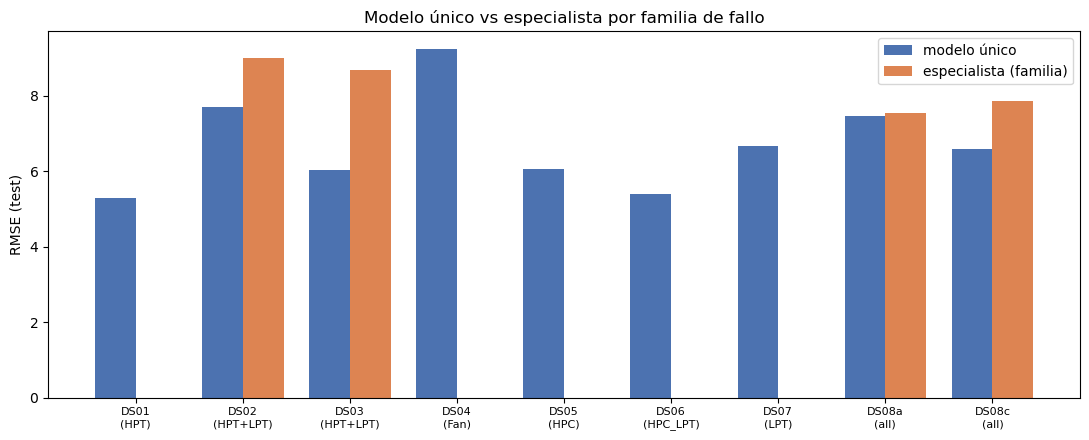

In [7]:
# Visual: RMSE único vs especialista por subconjunto
v = comp.copy(); x = np.arange(len(v)); w = 0.38
plt.figure(figsize=(11, 4.5))
plt.bar(x - w/2, v.RMSE_unico, w, label='modelo único', color='#4C72B0')
plt.bar(x + w/2, v.RMSE_espec.fillna(0), w, label='especialista (familia)', color='#DD8452')
plt.xticks(x, [f'{r.test}\n({r.familia})' for r in v.itertuples()], fontsize=8)
plt.ylabel('RMSE (test)'); plt.title('Modelo único vs especialista por familia de fallo')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Resultados obtenidos y decisión de arquitectura

**El modelo único gana SIEMPRE que existe comparación posible:**

| Subconjunto | Único | Especialista |
|---|---|---|
| DS02 | **7,69** | 8,99 |
| DS03 | **6,02** | 8,69 |
| DS08a | **7,47** | 7,53 |
| DS08c | **6,57** | 7,87 |
| **Agregado** | **6,94** | 8,27 |

Y en sesgo absoluto: **1,86 (único) frente a 3,64 (especialistas)** — la mitad.

Además, hay un límite estructural: **5 de los 9 subconjuntos no admiten especialista**, porque su
modo de fallo aparece una sola vez en el dataset (no hay con qué formar la "familia").

**Por qué gana el único:** los especialistas tienen menos motores cada uno (menos variedad de
vidas y regímenes), y el sesgo de vida corta se agrava dentro de cada familia. La variedad de la
flota completa regulariza mejor que la especialización.

**Decisión (definitiva para el proyecto): modelo único de flota para la prognosis.** Los modelos
por familia quedan descartados para RUL; la idea de "familia de fallo" reaparecerá, con otro
papel, en el diagnóstico (Fase 6).